**Objetivos de la Versión 1**

- Qué es un entorno.
- Qué es un estado.
- Cómo representar un entorno mediante una matriz.
- Cómo asignar recompensas a cada estado.
- Cómo visualizar el entorno.

**Recompensas**

| Estado       | Valor | Recompensa |
| ------------ | ----- | ---------- |
| Tierra firme | 0     | -1         |
| Agujero      | -1    | -10        |
| Salida       | 1     | +10        |


ENTORNO
[[ 0  0  0  0  0  0]
 [ 0 -1  0 -1  0  0]
 [ 0  0  0  0  0  0]
 [ 0 -1  0  0 -1  0]
 [ 0  0  0 -1  0  0]
 [ 0  0  0  0  0  1]]

RECOMPENSAS
[[ -1  -1  -1  -1  -1  -1]
 [ -1 -10  -1 -10  -1  -1]
 [ -1  -1  -1  -1  -1  -1]
 [ -1 -10  -1  -1 -10  -1]
 [ -1  -1  -1 -10  -1  -1]
 [ -1  -1  -1  -1  -1  10]]


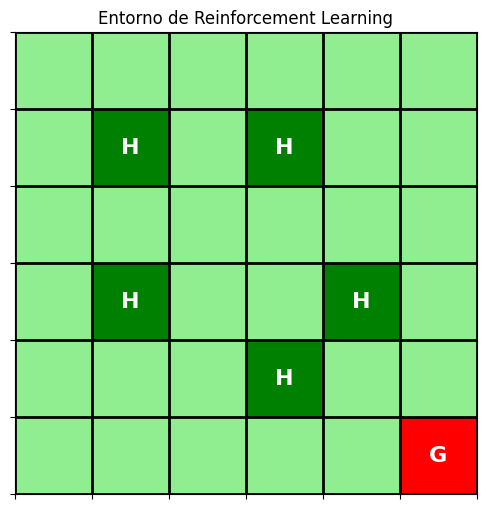

In [1]:
"""
=========================================================
LABORATORIO DE REINFORCEMENT LEARNING
VERSIÓN 1 - CREACIÓN DEL ENTORNO
=========================================================

Objetivo:

- Crear un entorno NxN
- Definir los estados
- Asociar recompensas
- Visualizar el mapa

Todavía NO existe aprendizaje.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# =====================================================
# CONFIGURACIÓN
# =====================================================

N = 6

# Representación del entorno
#
# 0  -> Tierra firme
# -1 -> Agujero
# 1  -> Salida
#

environment = np.zeros((N, N), dtype=int)

# =====================================================
# CREAR AGUJEROS
# =====================================================

holes = [

    (1,1),
    (1,3),
    (3,1),
    (3,4),
    (4,3)

]

for r, c in holes:
    environment[r, c] = -1

# =====================================================
# CREAR SALIDA
# =====================================================

goal = (5,5)

environment[goal] = 1

# =====================================================
# MATRIZ DE RECOMPENSAS
# =====================================================

rewards = np.full((N,N), -1)

for r,c in holes:
    rewards[r,c] = -10

rewards[goal] = 10

# =====================================================
# MOSTRAR MATRICES
# =====================================================

print("="*50)
print("ENTORNO")
print("="*50)

print(environment)

print()

print("="*50)
print("RECOMPENSAS")
print("="*50)

print(rewards)

# =====================================================
# VISUALIZACIÓN
# =====================================================

colors = ListedColormap([
    "green",      # agujero (-1)
    "lightgreen", # tierra (0)
    "red"         # salida (1)
])

display = environment + 1

plt.figure(figsize=(6,6))

plt.imshow(display, cmap=colors)

# Dibujar cuadrícula

plt.xticks(np.arange(-.5, N, 1), [])  # marcas en eje "x": empezar en -0.5 y avanzar de 1 en 1 hasta N-0.5
plt.yticks(np.arange(-.5, N, 1), [])  # marcas en eje "y": empezar en -0.5 y avanzar de 1 en 1 hasta N-0.5

plt.grid(color='black', linewidth=2)

# Escribir texto dentro de cada celda

for i in range(N):
    for j in range(N):

        if environment[i,j] == -1: # Hole
            txt = "H"

        elif environment[i,j] == 1: # salida
            txt = "G"

        else:
            txt = ""

        plt.text(
            j,
            i,
            txt,
            ha="center",
            va="center",
            fontsize=16,
            color="white",
            weight="bold"
        )

plt.title("Entorno de Reinforcement Learning")

plt.show()